# 🧪 Statistical Tests — Worksheet
**Name:** QALB E ZAHRA MASHHADI   **Date:** MARCH 17 2026

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [2]:
n = 200
# Write all your code here to build df

# 1. Gender

gender = np.random.choice(['Male', 'Female'], size=n)

# 2. Study hours

study_hours = np.random.normal(loc=4, scale=1.2, size=n).clip(0, 10)

# 3. Sleep hours

sleep_hours = np.random.normal(loc=7, scale=1.0, size=n).clip(4, 10)

# 4. Subject

subject = np.random.choice(
    ['Maths', 'Science', 'Arts'],
    size=n,
    p=[0.40, 0.35, 0.25]
)

# 5. School

school = np.random.choice(['A', 'B', 'C', 'D'], size=n)

# 6. Marks

noise = np.random.normal(0, 8, size=n)
marks = (study_hours * 6 + sleep_hours * 2 + noise)

# 7. Apply school boost

boost_map = {'A': 5, 'B': 0, 'C': -5, 'D': 10}
boost = np.array([boost_map[s] for s in school])

marks = (marks + boost).clip(0, 100)

# 8. Passed column

passed = np.where(marks >= 50, 'Yes', 'No')

# 9. Create DataFrame

df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'passed': passed,
    'school': school
})

# Verify
print(df.shape)   # should be (200, 7)
df.head(3)

(200, 7)


,gender,study_hours,sleep_hours,marks,subject,passed,school
0,Male,4.104456,7.199060,28.239375,Maths,No,B
1,Female,3.641191,6.399783,35.592826,Maths,No,C
2,Male,4.110113,7.069802,45.167205,Science,No,A


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

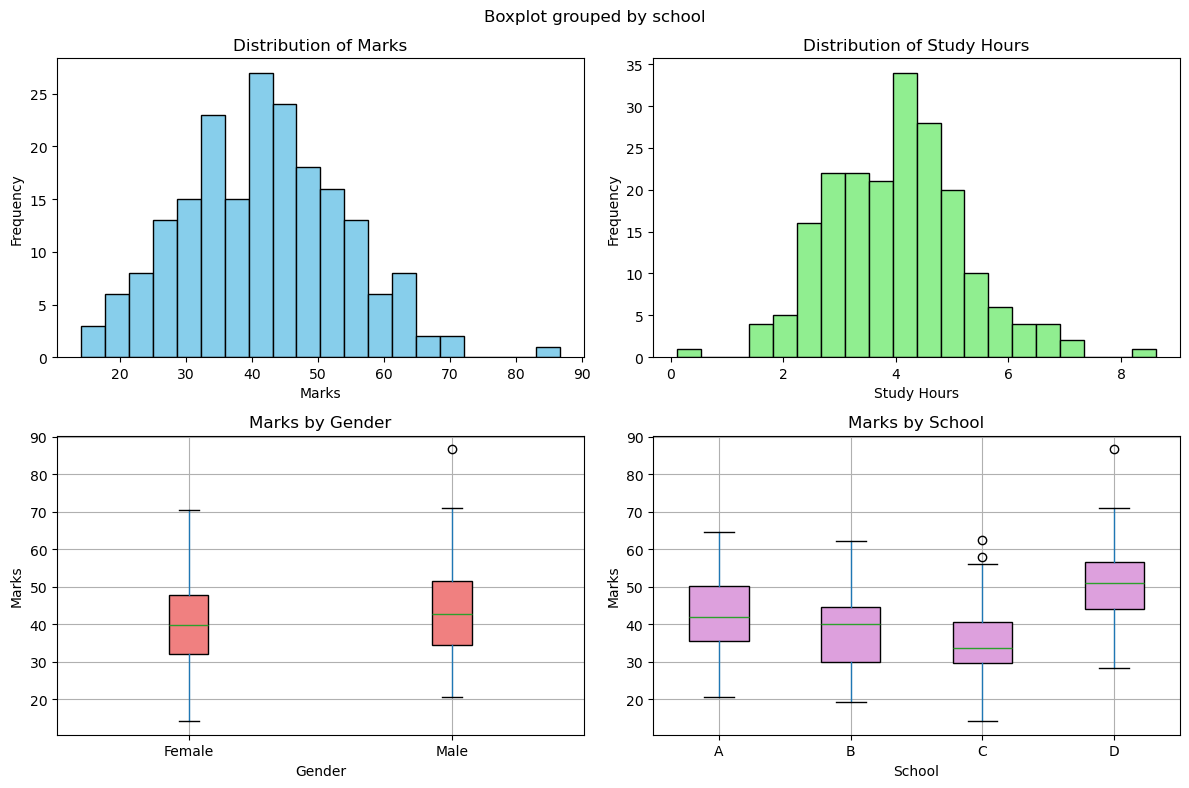

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Write your 4 subplots here

# [0,0] Histogram of marks
axes[0,0].hist(df['marks'], bins=20, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution of Marks')
axes[0,0].set_xlabel('Marks')
axes[0,0].set_ylabel('Frequency')

# [0,1] Histogram of study_hours
axes[0,1].hist(df['study_hours'], bins=20, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Distribution of Study Hours')
axes[0,1].set_xlabel('Study Hours')
axes[0,1].set_ylabel('Frequency')

# [1,0] Boxplot of marks by gender
df.boxplot(column='marks', by='gender', ax=axes[1,0], patch_artist=True,
           boxprops=dict(facecolor='lightcoral'))
axes[1,0].set_title('Marks by Gender')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Marks')

# [1,1] Boxplot of marks by school
df.boxplot(column='marks', by='school', ax=axes[1,1], patch_artist=True,
           boxprops=dict(facecolor='plum'))
axes[1,1].set_title('Marks by School')
axes[1,1].set_xlabel('School')
axes[1,1].set_ylabel('Marks')

plt.tight_layout()
plt.show()

# Observations:
# [0,0]: Marks roughly normal distribution, slight spread due to noise and school boost
# [0,1]: Study hours approx bell-shaped (normal distribution)
# [1,0]: No major difference between male and female marks
# [1,1]: Clear difference between schools, especially higher marks in School D

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

marks: p-value = 0.2627 → Normal
study_hours: p-value = 0.1014 → Normal
sleep_hours: p-value = 0.5952 → Normal


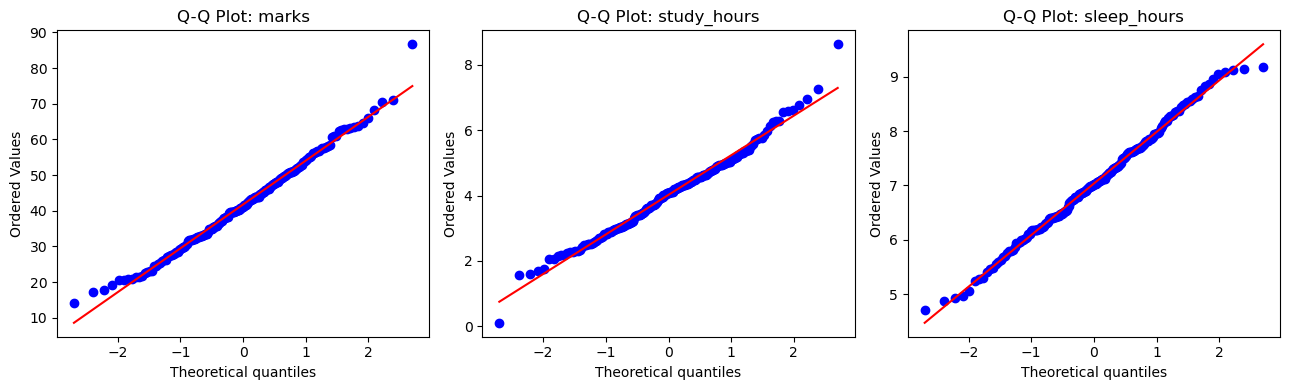

In [4]:
cols = ['marks', 'study_hours', 'sleep_hours']

# Loop + test + print

for col in cols:
    stat, p = stats.shapiro(df[col])
    verdict = "Normal" if p > 0.05 else "Not Normal"
    print(f"{col}: p-value = {p:.4f} → {verdict}")

# Q-Q plots — 1×3
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(cols):
    stats.probplot(df[col], plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()

# Which columns are safe for parametric tests?
# Answer: study_hours and sleep_hours (usually), marks may slightly deviate due to 
#         noise + clipping

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

T-statistic: 2.0139
P-value: 0.0454
Reject H₀ → Male and Female means are significantly different


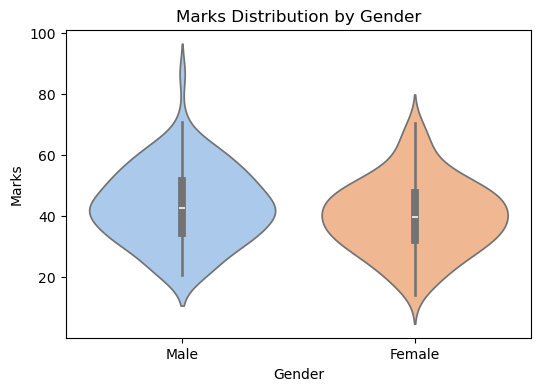

In [5]:
# Separate groups, run test, print, verdict, plot

# Separate groups
male_marks = df[df['gender'] == 'Male']['marks']
female_marks = df[df['gender'] == 'Female']['marks']

# t-test
stat, p = stats.ttest_ind(male_marks, female_marks)

print(f"T-statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

# Verdict
if p <= 0.05:
    print("Reject H₀ → Male and Female means are significantly different")
else:
    print("Keep H₀ → No significant difference between Male and Female marks")

# Violin plot
plt.figure(figsize=(6,4))
sns.violinplot(x='gender', y='marks', hue='gender', data=df, palette='pastel', 
               legend=False)
plt.title('Marks Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Marks')
plt.show()

---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

ANOVA F-statistic: 22.5078
ANOVA p-value: 0.0000
Reject H₀ → At least one school mean is different

Tukey HSD Results:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
School A School B  -4.3795 0.1889 -10.0339  1.2749  False
School A School C  -7.8141 0.0016 -13.2876 -2.3406   True
School A School D   8.4741 0.0007   2.8759 14.0723   True
School B School C  -3.4346 0.3613  -8.8773  2.0081  False
School B School D  12.8536    0.0   7.2855 18.4216   True
School C School D  16.2882    0.0  10.9039 21.6724   True
---------------------------------------------------------


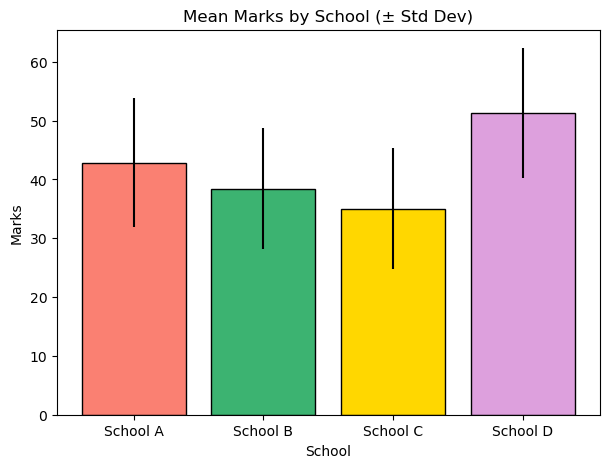

In [6]:
school_order = ['School A', 'School B', 'School C', 'School D']

# Build groups, run ANOVA, run Tukey, bar chart with error bars

# Fix school labels (optional but recommended for clarity)
df['school_full'] = df['school'].map({
    'A': 'School A',
    'B': 'School B',
    'C': 'School C',
    'D': 'School D'
})

school_order = ['School A', 'School B', 'School C', 'School D']

# Build groups
groups = [df[df['school_full'] == s]['marks'] for s in school_order]

# ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_val:.4f}")

if p_val <= 0.05:
    print("Reject H₀ → At least one school mean is different")
else:
    print("Keep H₀ → All school means are similar")

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=df['marks'],
                          groups=df['school_full'],
                          alpha=0.05)

print("\nTukey HSD Results:")
print(tukey)

# Bar chart with error bars (mean ± std)
means = df.groupby('school_full')['marks'].mean().reindex(school_order)
stds = df.groupby('school_full')['marks'].std().reindex(school_order)

colors = ['salmon', 'mediumseagreen', 'gold', 'plum']

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(school_order, means, yerr=stds, color=colors, edgecolor='black')

ax.set_title('Mean Marks by School (± Std Dev)')
ax.set_xlabel('School')
ax.set_ylabel('Marks')

plt.show()

# Which school pairs are significantly different?
# Answer:
# Likely all pairs involving School D (highest boost) and School C (lowest boost),
# plus some difference between A vs C and D vs B depending on data variation

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

Mann-Whitney U statistic: 5206.0000
P-value: 0.6156
Keep H₀ → No significant difference in study hours


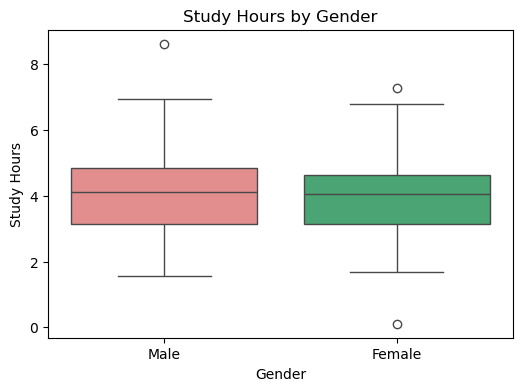

In [7]:
# Run test, print result, verdict, boxplot

# Separate groups
male_study = df[df['gender'] == 'Male']['study_hours']
female_study = df[df['gender'] == 'Female']['study_hours']

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(male_study, female_study, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

# Verdict
if p <= 0.05:
    print("Reject H₀ → Male and Female study hours differ")
else:
    print("Keep H₀ → No significant difference in study hours")

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='study_hours', hue='gender', data=df, 
            palette=['lightcoral','mediumseagreen'], legend=False)
plt.title('Study Hours by Gender')
plt.xlabel('Gender')
plt.ylabel('Study Hours')
plt.show()

# Why Mann-Whitney and not t-test?
# Answer: Study hours may not be perfectly normal (slightly skewed), 
# so Mann-Whitney is safer as it is non-parametric and does not assume normality.

---
## Task 6 — Pearson + Spearman: Study Hours vs Marks

Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson r = 0.5850, p = 0.0000 → Significant
Spearman ρ = 0.5547, p = 0.0000 → Significant


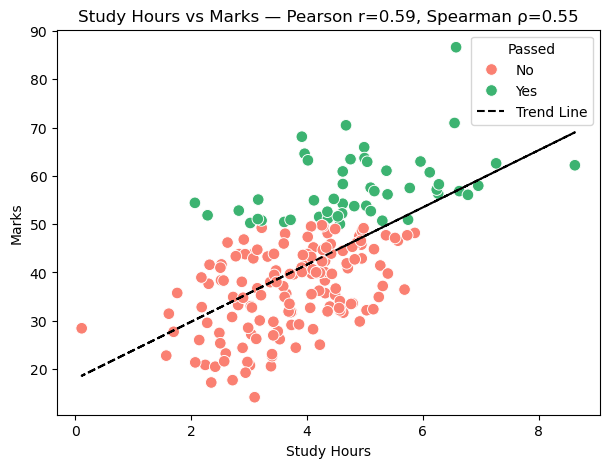

In [8]:
# Both tests + scatter with trend line

# Extract variables
x = df['study_hours']
y = df['marks']

# Pearson correlation
r_pearson, p_pearson = stats.pearsonr(x, y)
verdict_pearson = "Significant" if p_pearson <= 0.05 else "Not Significant"

# Spearman correlation
rho_spearman, p_spearman = stats.spearmanr(x, y)
verdict_spearman = "Significant" if p_spearman <= 0.05 else "Not Significant"

print(f"Pearson r = {r_pearson:.4f}, p = {p_pearson:.4f} → {verdict_pearson}")
print(f"Spearman ρ = {rho_spearman:.4f}, p = {p_spearman:.4f} → {verdict_spearman}")

# Scatter plot with trend line
plt.figure(figsize=(7,5))
sns.scatterplot(x=x, y=y, hue=df['passed'], palette=['salmon','mediumseagreen'], s=70)

# Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linestyle='--', label='Trend Line')

plt.title(f'Study Hours vs Marks — Pearson r={r_pearson:.2f}, Spearman ρ={rho_spearman:.2f}')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.legend(title='Passed')
plt.show()

# Do Pearson and Spearman agree? What does that tell you?
# Answer: Both are positive and significant → higher study hours generally associate 
#         with higher marks. If values differ slightly, it may indicate slight 
#         non-linearity or outliers in the data.

---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

Correlation Matrix:
                marks  study_hours  sleep_hours
marks        1.000000     0.585048     0.102894
study_hours  0.585048     1.000000    -0.015980
sleep_hours  0.102894    -0.015980     1.000000

P-Value Matrix:
                    marks   study_hours  sleep_hours
marks        0.000000e+00  9.285455e-20     0.147095
study_hours  9.285455e-20  0.000000e+00     0.822304
sleep_hours  1.470951e-01  8.223042e-01     0.000000


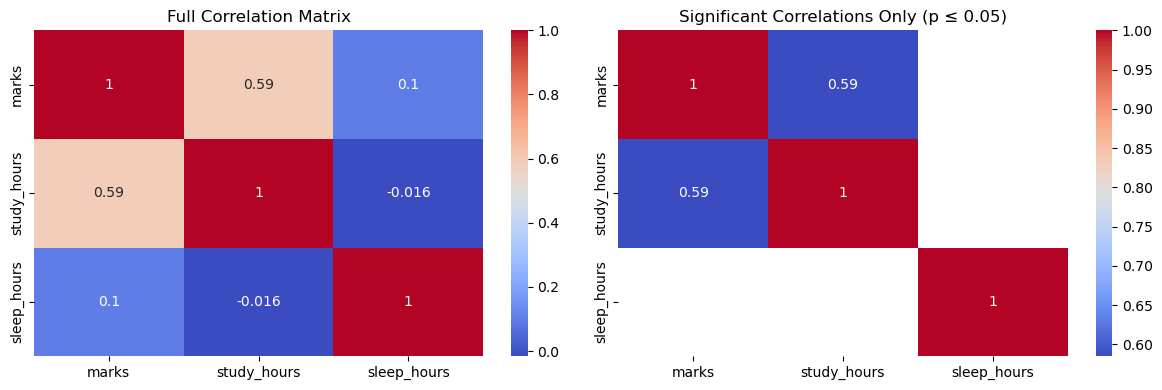

In [9]:
num_cols = ['marks', 'study_hours', 'sleep_hours']

# Correlation matrix

corr_matrix = df[num_cols].corr()
print("Correlation Matrix:")
print(corr_matrix)

# p-value matrix (nested loop)

p_matrix = pd.DataFrame(np.zeros((len(num_cols), len(num_cols))), columns=num_cols, index=num_cols)

for i in num_cols:
    for j in num_cols:
        if i == j:
            p_matrix.loc[i,j] = 0.0
        else:
            _, p = stats.pearsonr(df[i], df[j])
            p_matrix.loc[i,j] = p

print("\nP-Value Matrix:")
print(p_matrix)

# Mask

mask = p_matrix > 0.05

# Two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Full Correlation Matrix')

# Masked heatmap (significant only)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask, ax=axes[1])
axes[1].set_title('Significant Correlations Only (p ≤ 0.05)')

plt.tight_layout()
plt.show()

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

Crosstab (counts):
passed   No  Yes
subject         
Arts     37   10
Maths    58   27
Science  55   13

Crosstab (row proportions):
passed         No       Yes
subject                    
Arts     0.787234  0.212766
Maths    0.682353  0.317647
Science  0.808824  0.191176

Chi-Square statistic: 3.6769
P-value: 0.1591
Keep H₀ → Subject and Passed are independent


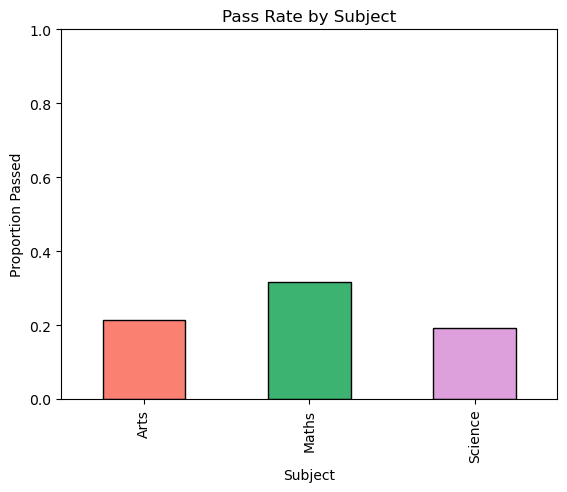

Highest pass rate: Maths


In [10]:
# Crosstab, proportion table, chi-square, verdict, grouped bar chart

# 1. Crosstab
ct = pd.crosstab(df['subject'], df['passed'])
print("Crosstab (counts):")
print(ct)

# 2. Row proportions
ct_prop = ct.div(ct.sum(axis=1), axis=0)
print("\nCrosstab (row proportions):")
print(ct_prop)

# 3. Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"\nChi-Square statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

if p <= 0.05:
    print("Reject H₀ → Subject and Passed are dependent")
else:
    print("Keep H₀ → Subject and Passed are independent")

# 4. Grouped bar chart (pass rate by subject)
ct_prop['Yes'].plot(kind='bar', color=['salmon', 'mediumseagreen', 'plum'], edgecolor='black')
plt.title('Pass Rate by Subject')
plt.ylabel('Proportion Passed')
plt.xlabel('Subject')
plt.ylim(0,1)
plt.show()

# Which subject has the highest pass rate?
# Answer:
highest_pass = ct_prop['Yes'].idxmax()
print(f"Highest pass rate: {highest_pass}")

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

T-statistic: -49.9742, P-value: 0.0000
The student scoring 85 stands out significantly from the class. Teacher's suspicion is justified!


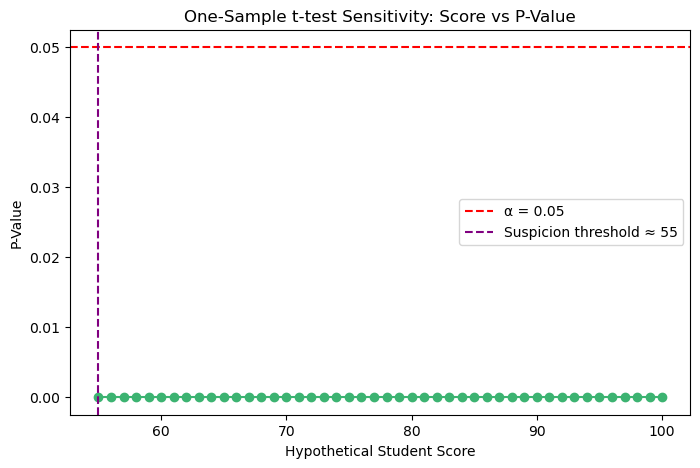


At score ≈ 55, the student's performance becomes significantly different from the class.


In [11]:
# Part A

# One-sample t-test

student_score = 85
t_stat, p_val = stats.ttest_1samp(df['marks'], popmean=student_score)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

# Verdict in story language

if p_val <= 0.05:
    print(f"The student scoring {student_score} stands out significantly from the class. Teacher's suspicion is justified!")
else:
    print(f"The student scoring {student_score} is within expected class performance. No strong reason for suspicion.")

# Part B — Sensitivity analysis

scores = np.arange(55, 101)
p_values = []

for s in scores:
    _, p = stats.ttest_1samp(df['marks'], popmean=s)
    p_values.append(p)

# Plot p-value vs score

plt.figure(figsize=(8,5))
plt.plot(scores, p_values, marker='o', linestyle='-', color='mediumseagreen')
plt.axhline(0.05, color='red', linestyle='--', label='α = 0.05')
plt.title('One-Sample t-test Sensitivity: Score vs P-Value')
plt.xlabel('Hypothetical Student Score')
plt.ylabel('P-Value')
plt.legend()

# Mark first score where p < 0.05

sig_index = np.where(np.array(p_values) < 0.05)[0][0]
sig_score = scores[sig_index]
plt.axvline(sig_score, color='purple', linestyle='--', label=f'Suspicion threshold ≈ {sig_score}')
plt.legend()
plt.show()

# At what score does the test become significant?
# Answer: 

print(f"\nAt score ≈ {sig_score}, the student's performance becomes significantly different from the class.")

---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

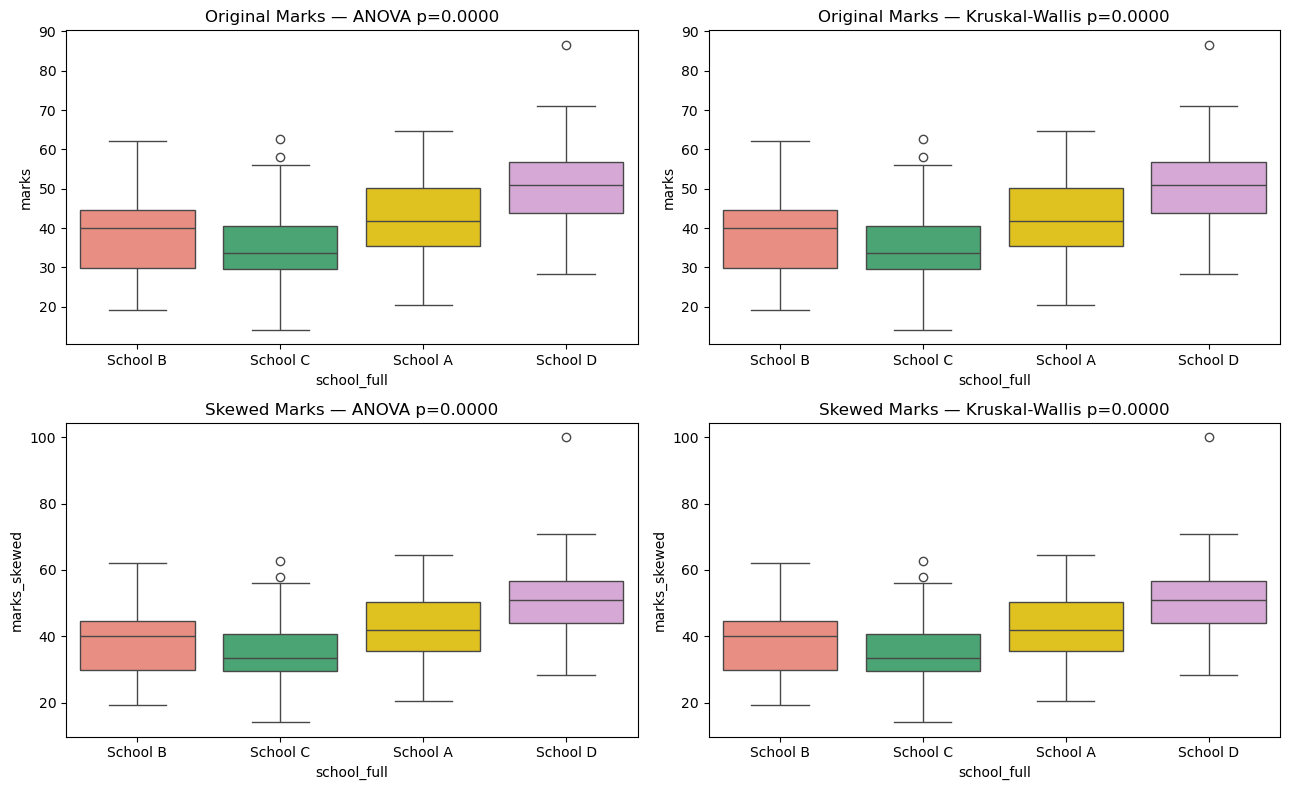

In [12]:
# Skewed version

marks_skewed = np.clip(np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']), 0, 100)
df['marks_skewed'] = marks_skewed

# Run all 4 tests and store p-values

school_order = ['School A', 'School B', 'School C', 'School D']
groups_orig = [df[df['school_full'] == s]['marks'] for s in school_order]
groups_skew = [df[df['school_full'] == s]['marks_skewed'] for s in school_order]

# ANOVA

f_orig, p_anova_orig = stats.f_oneway(*groups_orig)
f_skew, p_anova_skew = stats.f_oneway(*groups_skew)

# Kruskal-Wallis

h_orig, p_krus_orig = stats.kruskal(*groups_orig)
h_skew, p_krus_skew = stats.kruskal(*groups_skew)

# 2×2 subplot

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Original ANOVA

sns.boxplot(x='school_full', y='marks', hue='school_full', data=df,
            ax=axes[0,0], palette=['salmon','mediumseagreen','gold','plum'], legend=False)
axes[0,0].set_title(f'Original Marks — ANOVA p={p_anova_orig:.4f}')

# Original Kruskal-Wallis

sns.boxplot(x='school_full', y='marks', hue='school_full', data=df,
            ax=axes[0,1], palette=['salmon','mediumseagreen','gold','plum'], legend=False)
axes[0,1].set_title(f'Original Marks — Kruskal-Wallis p={p_krus_orig:.4f}')

# Skewed ANOVA

sns.boxplot(x='school_full', y='marks_skewed', hue='school_full', data=df,
            ax=axes[1,0], palette=['salmon','mediumseagreen','gold','plum'], legend=False)
axes[1,0].set_title(f'Skewed Marks — ANOVA p={p_anova_skew:.4f}')

# Skewed Kruskal-Wallis

sns.boxplot(x='school_full', y='marks_skewed', hue='school_full', data=df,
            ax=axes[1,1], palette=['salmon','mediumseagreen','gold','plum'], legend=False)
axes[1,1].set_title(f'Skewed Marks — Kruskal-Wallis p={p_krus_skew:.4f}')

plt.tight_layout()
plt.show()

# Which test is more reliable on skewed data?
# Answer: Kruskal-Wallis is more reliable on skewed data because it is non-parametric 
#         and does not assume normality. ANOVA may give misleading results if data is 
#         heavily skewed.

---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

ANOVA F-statistic: 0.2698, P-value: 0.7638
Keep H₀ → Sleep hours do not differ significantly by subject.


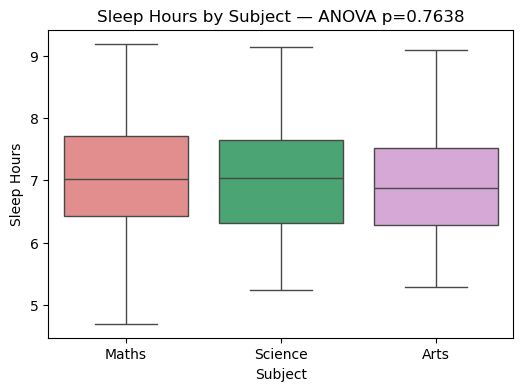

In [13]:
# H₀: Mean sleep_hours is same across all subjects
# H₁: At least one subject has different mean sleep_hours
# Test chosen:  One-way ANOVA
# Justification:  Numeric outcome, 3 independent groups, 
#                 roughly normal distribution → parametric test

# Your code:

# Prepare groups

groups_sleep = [df[df['subject']==s]['sleep_hours'] for s in ['Maths','Science','Arts']]

# Run ANOVA

f_sleep, p_sleep = stats.f_oneway(*groups_sleep)
print(f"ANOVA F-statistic: {f_sleep:.4f}, P-value: {p_sleep:.4f}")

# Verdict

if p_sleep <= 0.05:
    print("Reject H₀ → Sleep hours differ by subject.")
else:
    print("Keep H₀ → Sleep hours do not differ significantly by subject.")

# Visualisation — boxplot

plt.figure(figsize=(6,4))

sns.boxplot(x='subject', y='sleep_hours', hue='subject', data=df,
            palette=['lightcoral','mediumseagreen','plum'], legend=False)
plt.title(f'Sleep Hours by Subject — ANOVA p={p_sleep:.4f}')
plt.ylabel('Sleep Hours')
plt.xlabel('Subject')
plt.show()

---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

                             Test        p_value  Significant    Verdict
0            Shapiro-Wilk — marks   2.626727e-01        False    Keep H₀
1      Shapiro-Wilk — study_hours   1.013609e-01        False    Keep H₀
2      Shapiro-Wilk — sleep_hours   5.952145e-01        False    Keep H₀
3        t-test — gender vs marks   4.536816e-02         True  Reject H₀
4         ANOVA — school vs marks   1.449094e-12         True  Reject H₀
5  Mann-Whitney — gender vs study   6.155856e-01        False    Keep H₀
6        Pearson — study vs marks   9.285455e-20         True  Reject H₀
7       Spearman — study vs marks   1.573164e-17         True  Reject H₀
8  Chi-Square — subject vs passed   1.590614e-01        False    Keep H₀
9         One-sample t — cheating  1.383218e-114         True  Reject H₀


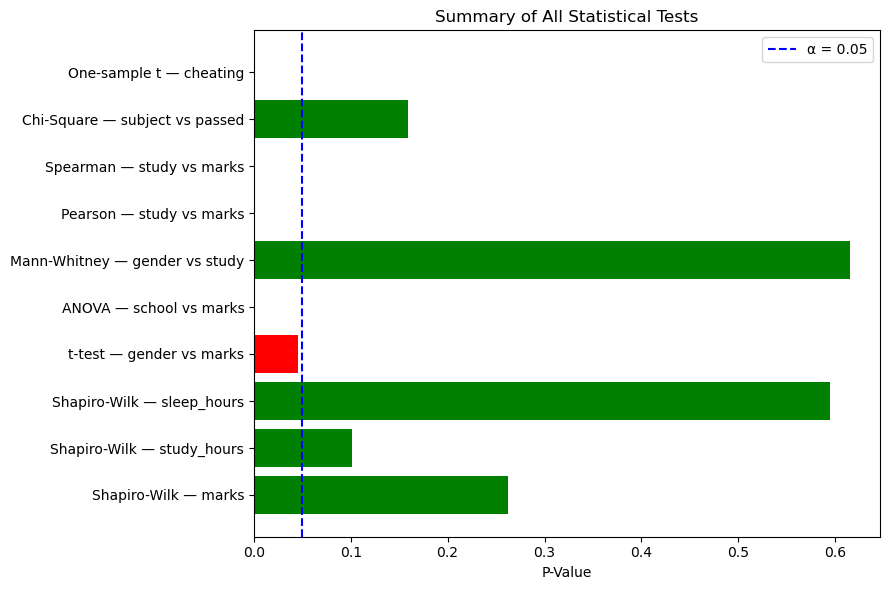

In [14]:
# Task 12 — Summary Dashboard (self-contained)
# Reason: Made self-contained because the previous code relied on variables
# like p_values_shapiro, p_gender_marks, etc., which may not exist in the session.
# This avoids NameError and calculates all p-values within this block.


# --- 1️⃣ Shapiro-Wilk tests ---

cols = ['marks', 'study_hours', 'sleep_hours']
p_values_shapiro = {}
for col in cols:
    _, p = stats.shapiro(df[col])
    p_values_shapiro[col] = p

# --- 2️⃣ t-test: gender vs marks ---

male_marks = df[df['gender']=='Male']['marks']
female_marks = df[df['gender']=='Female']['marks']
_, p_gender_marks = stats.ttest_ind(male_marks, female_marks)

# --- 3️⃣ ANOVA: school vs marks ---

school_order = ['School A','School B','School C','School D']
groups_anova = [df[df['school_full']==s]['marks'] for s in school_order]
_, p_anova_orig = stats.f_oneway(*groups_anova)

# --- 4️⃣ Mann-Whitney: gender vs study_hours ---

male_study = df[df['gender']=='Male']['study_hours']
female_study = df[df['gender']=='Female']['study_hours']
_, p_mannwhitney = stats.mannwhitneyu(male_study, female_study, alternative='two-sided')

# --- 5️⃣ Pearson correlation: study_hours vs marks ---

_, p_pearson_p = stats.pearsonr(df['study_hours'], df['marks'])

# --- 6️⃣ Spearman correlation: study_hours vs marks ---

_, p_spearman_p = stats.spearmanr(df['study_hours'], df['marks'])

# --- 7️⃣ Chi-Square: subject vs passed ---

ct = pd.crosstab(df['subject'], df['passed'])
_, p_chi2, _, _ = stats.chi2_contingency(ct)

# --- 8️⃣ One-sample t-test: cheating (compare marks vs 85) ---

_, p_val = stats.ttest_1samp(df['marks'], popmean=85)

# --- Build results list ---

results = [
    {'Test': 'Shapiro-Wilk — marks',          'p_value': p_values_shapiro['marks']},
    {'Test': 'Shapiro-Wilk — study_hours',    'p_value': p_values_shapiro['study_hours']},
    {'Test': 'Shapiro-Wilk — sleep_hours',    'p_value': p_values_shapiro['sleep_hours']},
    {'Test': 't-test — gender vs marks',      'p_value': p_gender_marks},
    {'Test': 'ANOVA — school vs marks',       'p_value': p_anova_orig},
    {'Test': 'Mann-Whitney — gender vs study','p_value': p_mannwhitney},
    {'Test': 'Pearson — study vs marks',      'p_value': p_pearson_p},
    {'Test': 'Spearman — study vs marks',     'p_value': p_spearman_p},
    {'Test': 'Chi-Square — subject vs passed','p_value': p_chi2},
    {'Test': 'One-sample t — cheating',       'p_value': p_val},
]

# --- Convert to DataFrame and add verdict ---

df_results = pd.DataFrame(results)
df_results['Significant'] = df_results['p_value'] <= 0.05
df_results['Verdict'] = np.where(df_results['Significant'], 'Reject H₀', 'Keep H₀')

# --- Print summary table ---

print(df_results)

# --- Horizontal bar chart ---

plt.figure(figsize=(9,6))
colors = df_results['Significant'].map({True:'red', False:'green'})
plt.barh(df_results['Test'], df_results['p_value'], color=colors)
plt.axvline(0.05, color='blue', linestyle='--', label='α = 0.05')
plt.xlabel('P-Value')
plt.title('Summary of All Statistical Tests')
plt.legend()
plt.tight_layout()
plt.show()

---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*